# Exploración de datos y descripción

Siempre será importante analizar el conjunto de datos, realizar algunos gráficos que puedan dar nociones de los patrones, etc.

## Importación de librerías

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

In [2]:
# Por preferencia al mostrar los números, ase ajustarán a 2 decimales

pd.set_option("display.float_format", "{:.2f}".format)

## Cargar los datos

Recordemos que el dataset correcto fue almacenado con el nombre de `02_datos_con_tipo_de_dato_ajustado_titanic.parquet`

In [3]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

In [4]:
DATA_DIR


PosixPath('/mnt/c/Users/david.palacio/Documents/projects/DataAI-Fundamentos-Aplicaciones/Analitica/proyectos/titanic/datos')

In [19]:
datos_titanic = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_titanic.parquet", engine="pyarrow")

In [14]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(2), float64(2), int64(1), int8(2), object(1)
memory usage: 47.7+ KB


In [26]:
datos_titanic["pclass"] = pd.Categorical(
    datos_titanic["pclass"], categories=[3, 2, 1], ordered=True
)

In [27]:
datos_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   category
 1   survived  1309 non-null   bool    
 2   name      1309 non-null   object  
 3   sex       1309 non-null   category
 4   age       1046 non-null   float64 
 5   sibsp     1309 non-null   int8    
 6   parch     1309 non-null   int8    
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: bool(1), category(3), float64(2), int8(2), object(1)
memory usage: 38.9+ KB


In [22]:
datos_titanic.shape

(1309, 9)

In [23]:
datos_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked
0,1,True,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,211.34,S
1,1,True,"Allison, Master. Hudson Trevor",male,0.92,1,2,151.55,S
2,1,False,"Allison, Miss. Helen Loraine",female,2.00,1,2,151.55,S
3,1,False,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,151.55,S
4,1,False,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,151.55,S


In [28]:
# Verificamos si hay valores nulos en el DataFrame

datos_titanic.isnull().sum()

pclass        0
survived      0
name          0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

## Variables Numéricas

Una forma sencilla de tener un resumen de las variables numéricas podrías ser:

In [29]:
datos_titanic.describe()

,age,sibsp,parch,fare
count,1046.00,1309.00,1309.00,1308.00
mean,29.88,0.50,0.39,33.30
std,14.41,1.04,0.87,51.76
min,0.17,0.00,0.00,0.00
25%,21.00,0.00,0.00,7.90
50%,28.00,0.00,0.00,14.45
75%,39.00,1.00,0.00,31.27
max,80.00,8.00,9.00,512.33


## Variables Categóricas

In [30]:
# Descripción de las variables categóricas

datos_titanic.describe(include="category")

,pclass,sex,embarked
count,1309,1309,1307
unique,3,2,3
top,3,male,S
freq,709,843,914


## Análisis Univariado

La variable objetivo es `survived`.

### Variable Objetivo

<Axes: title={'center': 'Pasajeros sobrevivientes'}, xlabel='survived'>

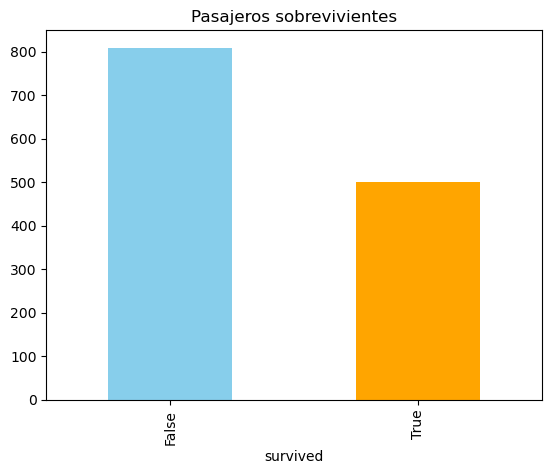

In [31]:
datos_titanic["survived"].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title="Pasajeros sobrevivientes"
)

### Variables Numéricas

In [32]:
columnas_numericas = list(datos_titanic.select_dtypes(include=["number"]).columns)
columnas_numericas

['age', 'sibsp', 'parch', 'fare']

#### Edad

In [33]:
column = "age"

datos_titanic[column].describe()

count   1046.00
mean      29.88
std       14.41
min        0.17
25%       21.00
50%       28.00
75%       39.00
max       80.00
Name: age, dtype: float64

In [34]:
# ¿Cuántos valores únicos de edad hay?

datos_titanic[column].nunique()

98

<Axes: title={'center': 'age histogram'}, ylabel='Frequency'>

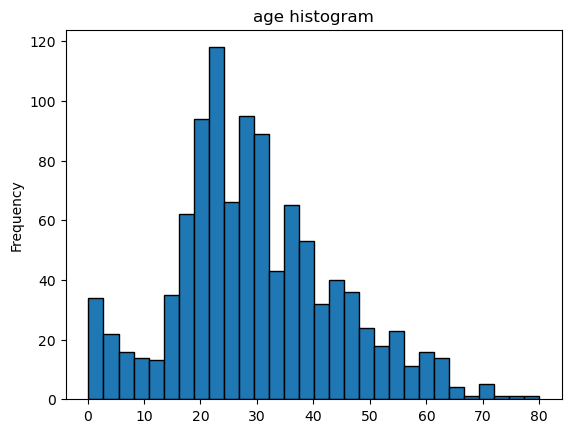

In [35]:
# Histograma con todas las edades

datos_titanic[column].plot(
    kind="hist", bins=30, edgecolor="black", title=f"{column} histogram"
)